# DeFi Blockchain Data Analysis + cadCAD Modelling


- Pulling live ETH/BTC prices from CoinGecko
- Fetching on-chain Ethereum data from Etherscan
- Querying Uniswap V3 pool data from The Graph
- Clustering market regimes with K-Means
- Modelling a DeFi AMM pool with cadCAD



In [1]:
# BLOCK 1 - Install packages
# Run this first, it only needs to run once per Colab session
!pip install -q requests pandas numpy matplotlib seaborn scikit-learn cadCAD
print('Done installing packages.')

Done installing packages.


- requests: Fetch data from APIs
- pandas: Data manipulation
- numpy: Numerical operations
- matplotlib & Seaborn:Data visualization
- scikit-learn:Machine learning (K-Means clustering)
- cadCAD:Blockchain economic simulations

In [2]:
# BLOCK 2 - Imports and API keys
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime, timedelta

warnings.filterwarnings('ignore')
plt.style.use('dark_background')

# API keys - these are pre-filled for you
COINGECKO_KEY = 'CG-wQuXibxjo6BZS6e2MMQB3y1S'
ETHERSCAN_KEY = 'REZAZVUXMZ258XECZ54HEMA49MKTA45YXY'
THEGRAPH_KEY  = '83984585a228ad2b12fc7325458dd5e7'

print('Config ready.')

Config ready.


In [ ]:
# BLOCK 3 - Fetch ETH and BTC price history from CoinGecko
# CoinGecko gives us 365 days of daily price, volume, market cap for free
# Purpose : Load Python modules and define API keys.
''' 
#CoinGecko API provides:
- Price
- Market cap
- Trading volume
 '''

def get_price_history(coin, days=365):
    # Try the pro endpoint first, fall back to the free one
    for url in ['https://pro-api.coingecko.com/api/v3', 'https://api.coingecko.com/api/v3']:
        headers = {'x-cg-pro-api-key': COINGECKO_KEY} if 'pro' in url else {}
        try:
            r = requests.get(
                f'{url}/coins/{coin}/market_chart',
                headers=headers,
                params={'vs_currency': 'usd', 'days': days, 'interval': 'daily'},
                timeout=15
            )
            if r.status_code == 200:
                d = r.json()
                df = pd.DataFrame(d['prices'], columns=['timestamp', 'price'])
                df['volume']     = [x[1] for x in d['total_volumes']]
                df['market_cap'] = [x[1] for x in d['market_caps']]
                df['date']       = pd.to_datetime(df['timestamp'], unit='ms').dt.normalize()
                df               = df.set_index('date').drop('timestamp', axis=1)
                print(f'  {coin}: {len(df)} days from {df.index[0].date()} to {df.index[-1].date()}')
                return df
        except Exception as e:
            print(f'  Tried {url} - failed: {e}')
    raise RuntimeError(f'Could not fetch data for {coin}')

print('Fetching price data...')
eth = get_price_history('ethereum', days=365)
btc = get_price_history('bitcoin',  days=365)

# Add daily return column
eth['return'] = eth['price'].pct_change()
btc['return'] = btc['price'].pct_change()

print(f'\nETH price today: ${eth.price.iloc[-1]:,.0f}')
print(f'BTC price today: ${btc.price.iloc[-1]:,.0f}')

Fetching price data...
  ethereum: 366 days from 2025-03-11 to 2026-03-10
  bitcoin: 366 days from 2025-03-11 to 2026-03-10

ETH price today: $2,029
BTC price today: $69,535


In [18]:
print(eth)

                  price        volume    market_cap    return
date                                                         
2025-03-11  1879.123105  3.657732e+10  2.267135e+11       NaN
2025-03-12  1921.309923  3.004660e+10  2.320249e+11  0.022450
2025-03-13  1910.655138  2.449931e+10  2.304437e+11 -0.005546
2025-03-14  1862.794937  1.921241e+10  2.246589e+11 -0.025049
2025-03-15  1910.666270  1.294997e+10  2.304769e+11  0.025699
...                 ...           ...           ...       ...
2026-03-07  1980.778284  1.931550e+10  2.391651e+11 -0.045188
2026-03-08  1969.693798  9.708504e+09  2.377054e+11 -0.005596
2026-03-09  1938.624925  1.625696e+10  2.341305e+11 -0.015773
2026-03-10  1992.355229  2.394877e+10  2.405688e+11  0.027716
2026-03-10  2029.336292  2.394635e+10  2.446477e+11  0.018561

[366 rows x 4 columns]


In [19]:
print(btc)

                   price        volume    market_cap    return
date                                                          
2025-03-11  78783.940579  4.998369e+10  1.563547e+12       NaN
2025-03-12  82799.108029  5.640446e+10  1.642997e+12  0.050964
2025-03-13  83884.245788  4.178219e+10  1.662503e+12  0.013106
2025-03-14  81098.900524  3.258359e+10  1.608477e+12 -0.033205
2025-03-15  83971.709161  2.857148e+10  1.665726e+12  0.035424
...                  ...           ...           ...       ...
2026-03-07  68148.283400  4.642799e+10  1.364074e+12 -0.038472
2026-03-08  67271.190778  2.458885e+10  1.345067e+12 -0.012870
2026-03-09  66036.157824  3.584585e+10  1.321622e+12 -0.018359
2026-03-10  68459.315371  5.241955e+10  1.369956e+12  0.036694
2026-03-10  69534.985030  5.203231e+10  1.390833e+12  0.015713

[366 rows x 4 columns]


- Price chart:	Market trend
- Returns distribution :	Volatility
- Rolling correlation :	ETH vs BTC relation
- Drawdown :Maximum loss from peak

This helps identify bull/bear periods.

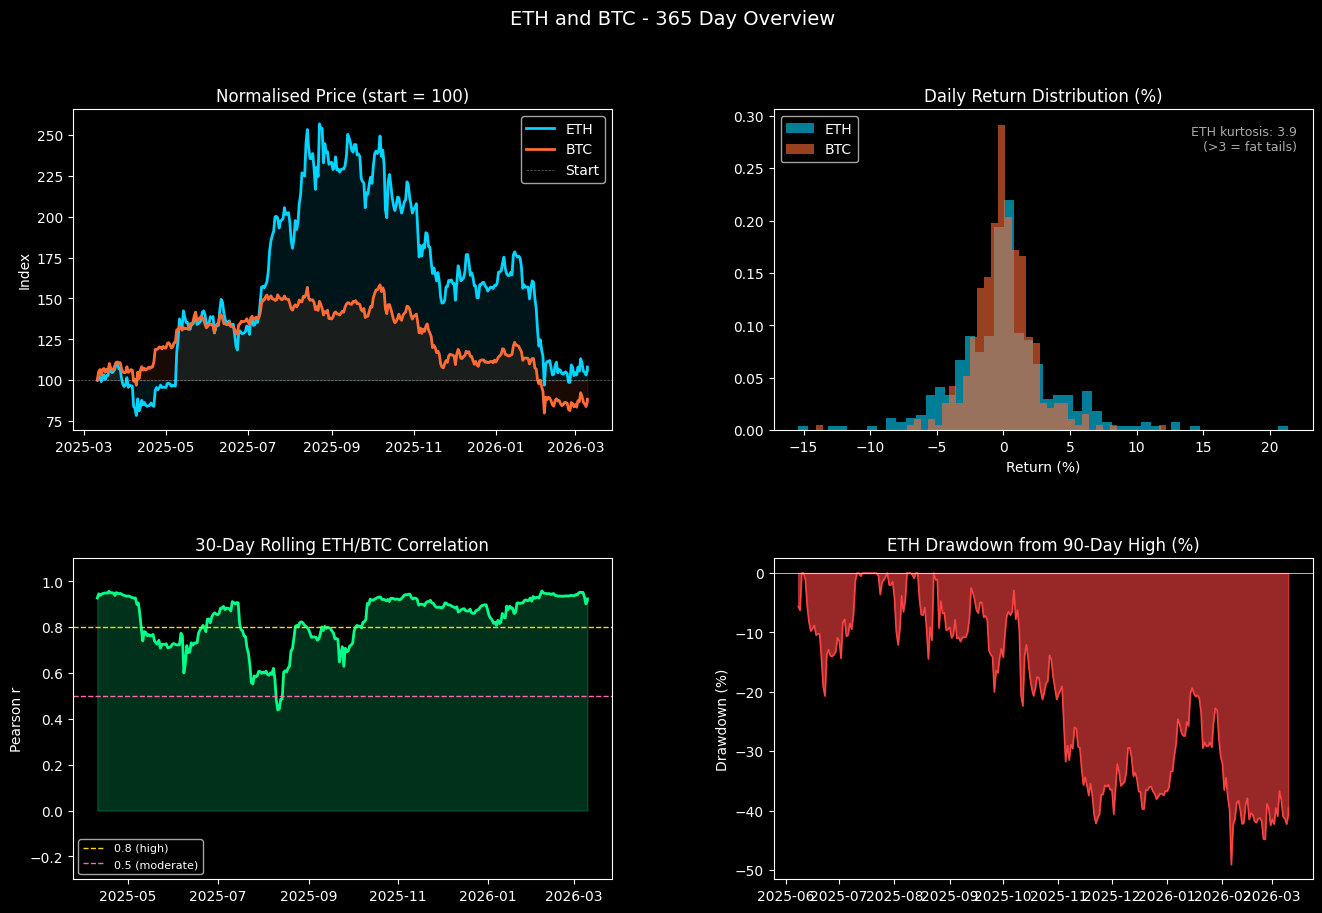

Chart saved as 01_price_overview.png


In [4]:
# BLOCK 4 - Visualise prices and returns
# Four charts: price, returns distribution, rolling correlation, drawdown

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('ETH and BTC - 365 Day Overview', fontsize=14)
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# Chart 1: Normalised price (both start at 100 so we can compare)
ax = axes[0, 0]
eth_norm = eth['price'] / eth['price'].iloc[0] * 100
btc_norm = btc['price'] / btc['price'].iloc[0] * 100
ax.plot(eth_norm, color='#00d4ff', lw=2, label='ETH')
ax.plot(btc_norm, color='#ff6b35', lw=2, label='BTC')
ax.axhline(100, color='white', lw=0.5, ls='--', alpha=0.4, label='Start')
ax.fill_between(eth_norm.index, 100, eth_norm, alpha=0.1, color='#00d4ff')
ax.fill_between(btc_norm.index, 100, btc_norm, alpha=0.1, color='#ff6b35')
ax.set_title('Normalised Price (start = 100)')
ax.set_ylabel('Index')
ax.legend()

# Chart 2: Daily return distribution - useful to see how volatile each coin is
ax = axes[0, 1]
ax.hist(eth['return'].dropna() * 100, bins=50, alpha=0.6, color='#00d4ff', label='ETH', density=True)
ax.hist(btc['return'].dropna() * 100, bins=50, alpha=0.6, color='#ff6b35', label='BTC', density=True)
ax.set_title('Daily Return Distribution (%)')
ax.set_xlabel('Return (%)')
ax.legend()
eth_kurt = eth['return'].dropna().kurt()
ax.text(0.97, 0.95, f'ETH kurtosis: {eth_kurt:.1f}\n(>3 = fat tails)',
        transform=ax.transAxes, ha='right', va='top', fontsize=9, color='#aaa')

# Chart 3: Rolling 30-day correlation between ETH and BTC returns
# When correlation is high, they move together. When it drops, ETH has its own story.
ax = axes[1, 0]
both = pd.concat([eth['return'].rename('eth'), btc['return'].rename('btc')], axis=1).dropna()
roll_corr = both['eth'].rolling(30).corr(both['btc'])
ax.plot(roll_corr, color='#00ff88', lw=2)
ax.fill_between(roll_corr.index, roll_corr, alpha=0.2, color='#00ff88')
ax.axhline(0.8, color='#ffd700', ls='--', lw=1, label='0.8 (high)')
ax.axhline(0.5, color='#ff69b4', ls='--', lw=1, label='0.5 (moderate)')
ax.set_title('30-Day Rolling ETH/BTC Correlation')
ax.set_ylabel('Pearson r')
ax.set_ylim(-0.3, 1.1)
ax.legend(fontsize=8)

# Chart 4: ETH drawdown from 90-day high
# Drawdown shows how far price has fallen from its recent peak
ax = axes[1, 1]
peak = eth['price'].rolling(90).max()
drawdown = (eth['price'] - peak) / peak * 100
ax.fill_between(drawdown.index, drawdown, 0, color='#ff4444', alpha=0.6)
ax.plot(drawdown, color='#ff4444', lw=1)
ax.set_title('ETH Drawdown from 90-Day High (%)')
ax.set_ylabel('Drawdown (%)')
ax.axhline(0, color='white', lw=0.5)

plt.savefig('01_price_overview.png', dpi=130, bbox_inches='tight')
plt.show()
print('Chart saved as 01_price_overview.png')

In [5]:
# BLOCK 5 - Fetch on-chain data from Etherscan (free endpoints only)
# Etherscan V2 API: chainid=1 = Ethereum mainnet
# Free tier gives us: gas oracle, ETH price, supply, current block number
# Note: historical daily stats (dailytx, dailyavggas) require a paid Pro plan

import time # Import the time module

BASE = 'https://api.etherscan.io/v2/api'

def etherscan(module, action, **kwargs):
    params = {'chainid': 1, 'module': module, 'action': action,
              'apikey': ETHERSCAN_KEY, **kwargs}
    r    = requests.get(BASE, params=params, timeout=15)
    data = r.json()

    # Regular Etherscan response: {"status": "1", "message": "OK", "result": ...}
    if data.get('status') == '1' or data.get('message') == 'OK':
        return data['result']

    # JSON-RPC proxy response (proxy module): {"jsonrpc": "2.0", "result": ..., "id": ...}
    # No status/message fields - just check jsonrpc key and result exists
    if 'jsonrpc' in data and 'result' in data:
        return data['result']

    raise RuntimeError(f"Etherscan error: {data.get('message')} -> {data.get('result')}")

# 1. Gas oracle - current network congestion
print('Fetching gas oracle...')
gas      = etherscan('gastracker', 'gasoracle')
time.sleep(1) # Add delay to respect rate limits
gas_safe = float(gas['SafeGasPrice'])
gas_std  = float(gas['ProposeGasPrice'])
gas_fast = float(gas['FastGasPrice'])
print(f'  Safe:     {gas_safe:.4f} Gwei')
print(f'  Standard: {gas_std:.4f} Gwei')
print(f'  Fast:     {gas_fast:.4f} Gwei')

# 2. ETH price from Etherscan - cross-check against CoinGecko
print('\nFetching ETH price from Etherscan...')
eth_price_data  = etherscan('stats', 'ethprice')
time.sleep(1) # Add delay to respect rate limits
eth_usd_ethscan = float(eth_price_data['ethusd'])
eth_btc_ethscan = float(eth_price_data['ethbtc'])
print(f'  ETH/USD: ${eth_usd_ethscan:,.2f}')
print(f'  ETH/BTC: {eth_btc_ethscan:.6f}')

# 3. Current block number - proxy returns hex, convert to int
print('\nFetching current block number...')
block_hex = etherscan('proxy', 'eth_blockNumber')
time.sleep(1) # Add delay to respect rate limits
block_num = int(block_hex, 16)
print(f'  Current block: {block_num:,}')
blocks_per_day = 86400 // 12   # ~1 block per 12 seconds post-Merge
print(f'  Approx {blocks_per_day:,} blocks/day')

# 4. Total ETH supply
print('\nFetching ETH supply...')
supply_eth = int(etherscan('stats', 'ethsupply')) / 1e18

print(f'  Total supply: {supply_eth:,.0f} ETH')

# Price cross-check
eth_price_cg = eth['price'].iloc[-1]
diff_pct     = abs(eth_price_cg / eth_usd_ethscan - 1) * 100
print(f'\nPrice cross-check:')
print(f'  CoinGecko:  ${eth_price_cg:,.2f}')
print(f'  Etherscan:  ${eth_usd_ethscan:,.2f}')
print(f'  Difference: {diff_pct:.3f}%  (should be < 0.5%)')

Fetching gas oracle...
  Safe:     0.0414 Gwei
  Standard: 0.0455 Gwei
  Fast:     0.0455 Gwei

Fetching ETH price from Etherscan...
  ETH/USD: $2,028.55
  ETH/BTC: 0.029177

Fetching current block number...
  Current block: 24,624,456
  Approx 7,200 blocks/day

Fetching ETH supply...
  Total supply: 122,373,866 ETH

Price cross-check:
  CoinGecko:  $2,029.34
  Etherscan:  $2,028.55
  Difference: 0.039%  (should be < 0.5%)


In [21]:
print(eth_price_data)

{'ethbtc': '0.029176907156518', 'ethbtc_timestamp': '1773114880', 'ethusd': '2028.55259918986', 'ethusd_timestamp': '1773114886'}


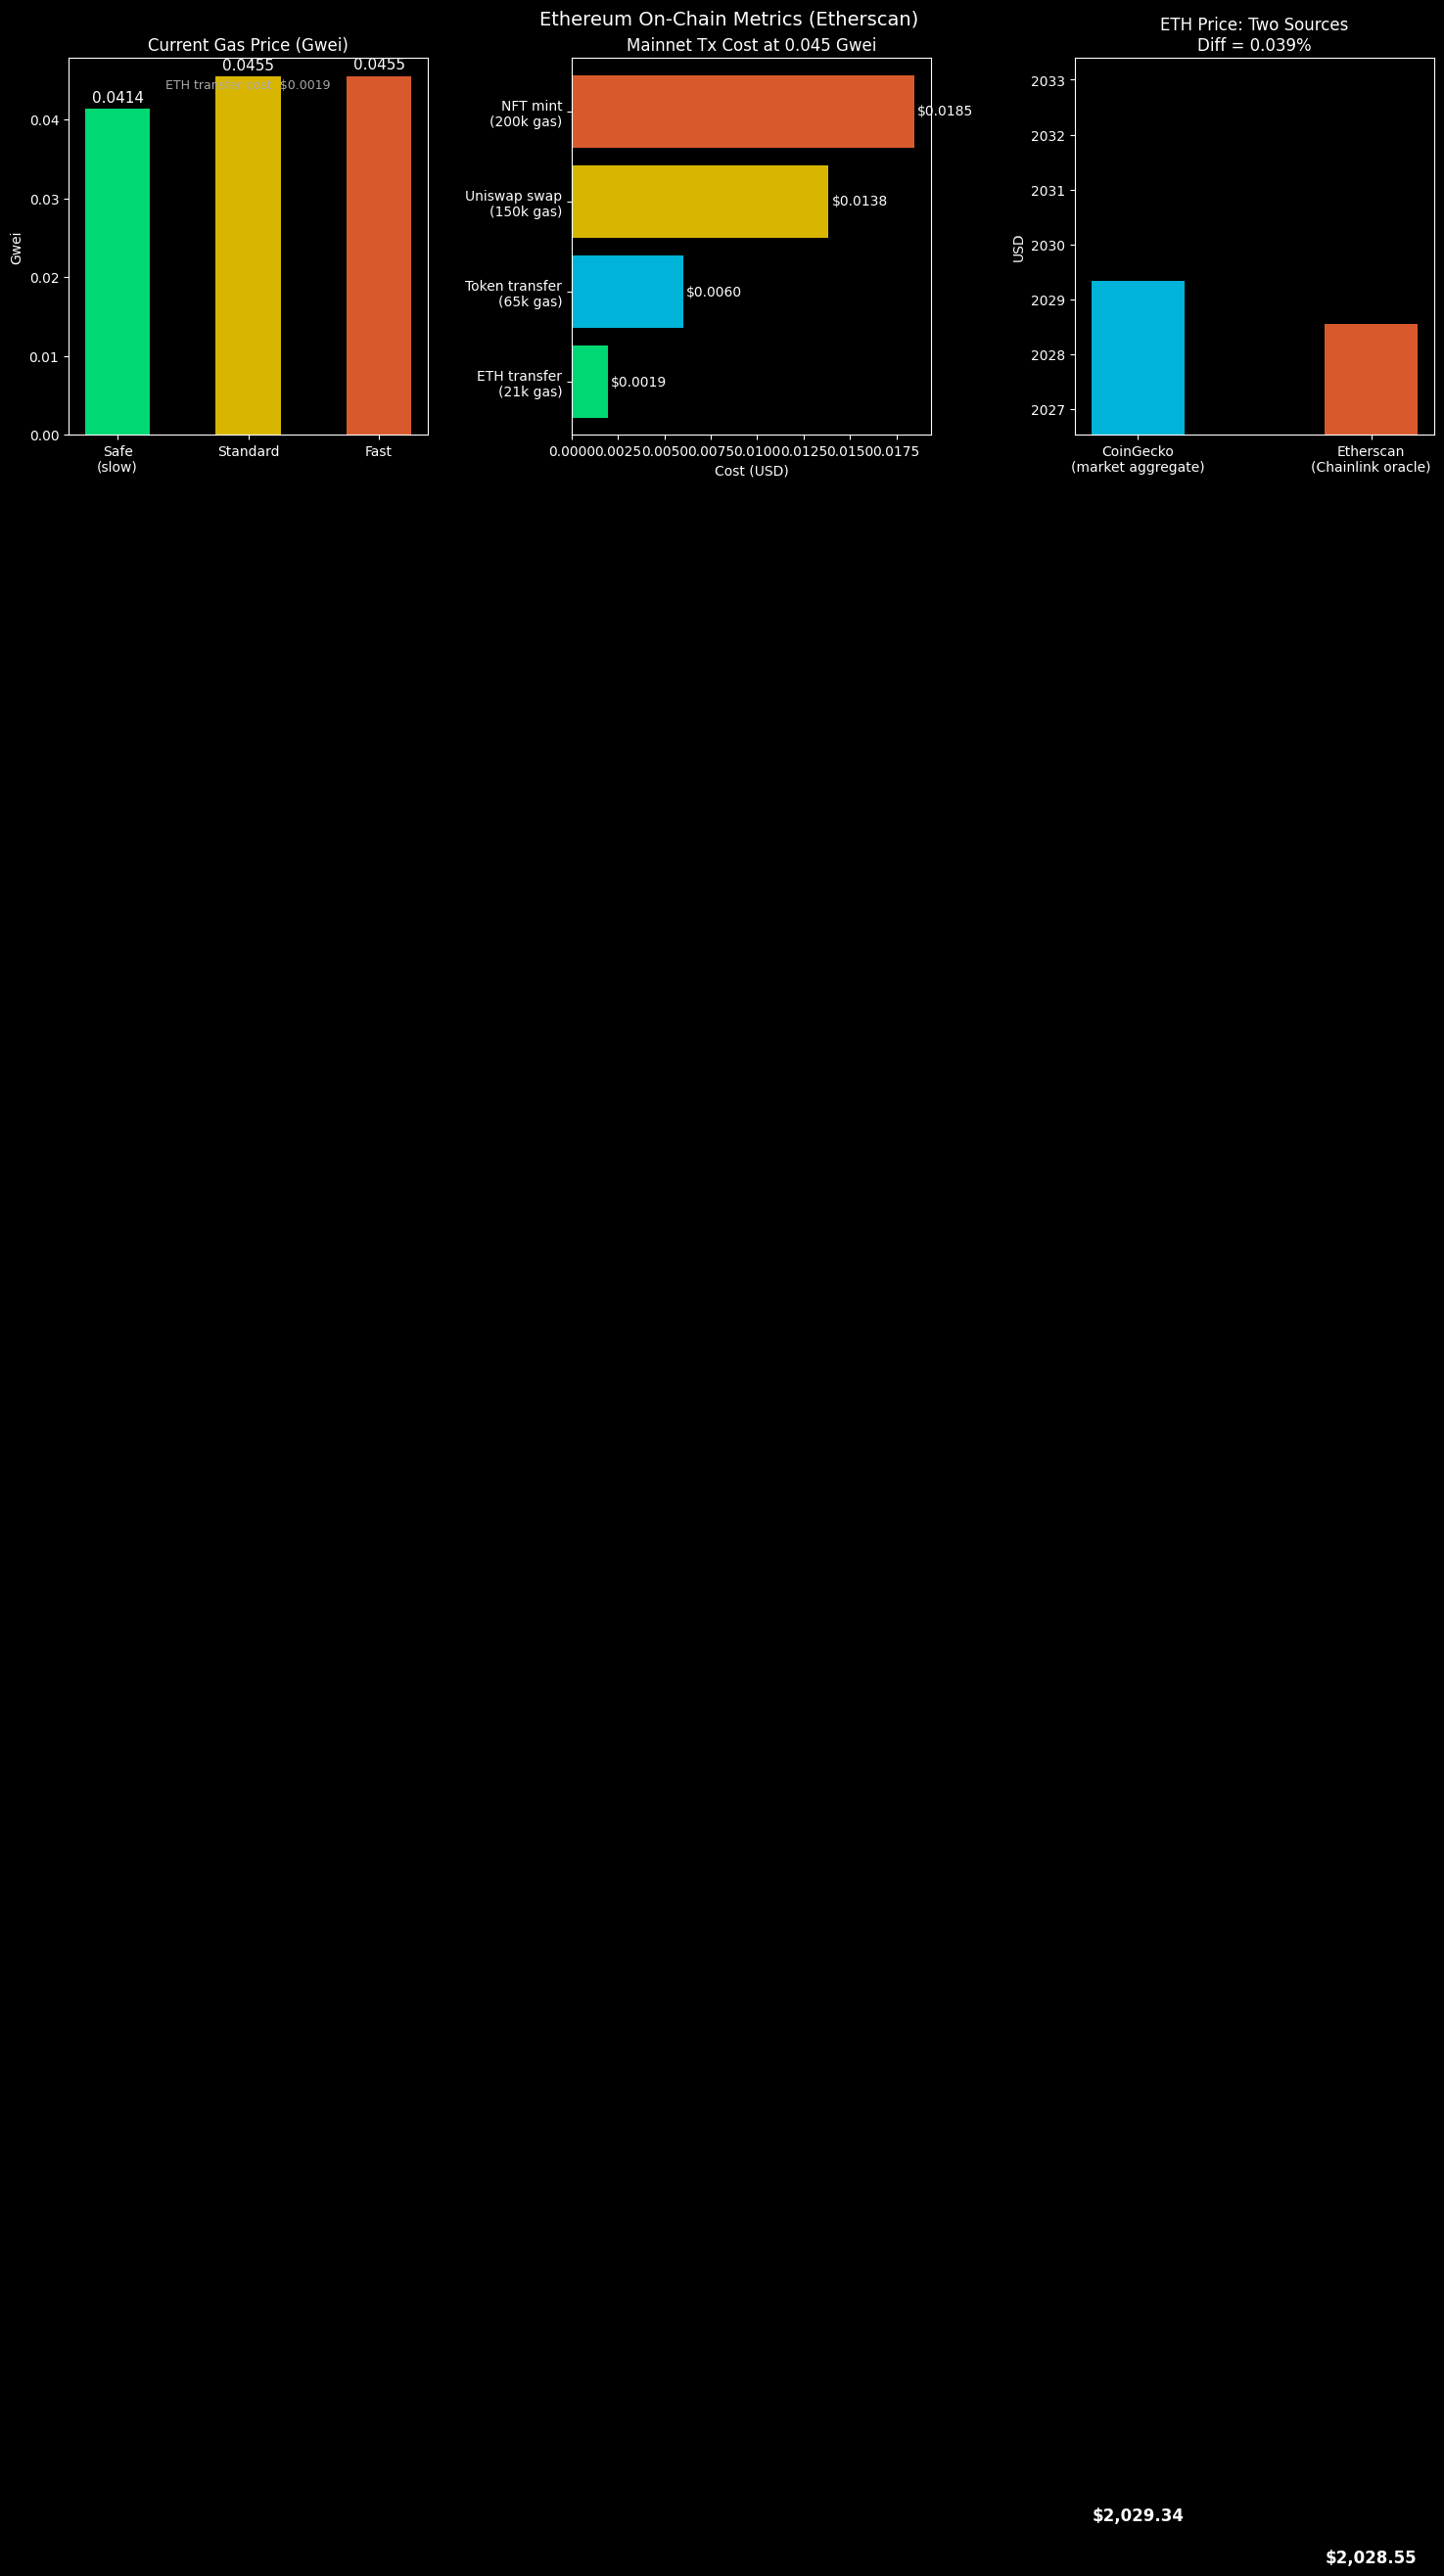

Chart saved as 02_onchain.png

Fun fact: block 24,624,456 / 7,200 blocks per day = 9.4 years of chain history


In [6]:
# BLOCK 6 - Visualise on-chain metrics
# Three charts using only the free data we actually fetched

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Ethereum On-Chain Metrics (Etherscan)', fontsize=14)
plt.subplots_adjust(wspace=0.4)

# Chart 1: Gas price breakdown
ax = axes[0]
labels_g = ['Safe\n(slow)', 'Standard', 'Fast']
values_g = [gas_safe, gas_std, gas_fast]
colors_g = ['#00ff88', '#ffd700', '#ff6b35']
bars = ax.bar(labels_g, values_g, color=colors_g, width=0.5, alpha=0.85)
for bar, val in zip(bars, values_g):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
            f'{val:.4f}', ha='center', fontsize=11, color='white')
ax.set_title('Current Gas Price (Gwei)')
ax.set_ylabel('Gwei')
cost_usd = gas_std * 21_000 * 1e-9 * eth_usd_ethscan
ax.text(0.5, 0.92, f'ETH transfer cost: ${cost_usd:.4f}',
        transform=ax.transAxes, ha='center', fontsize=9, color='#aaa')

# Chart 2: Transaction cost for different operation types
ax = axes[1]  # was axes[2] — bug: overwrote chart 3's axis
ops = {
    'ETH transfer\n(21k gas)':   gas_std * 21_000  * 1e-9 * eth_usd_ethscan,
    'Token transfer\n(65k gas)': gas_std * 65_000  * 1e-9 * eth_usd_ethscan,
    'Uniswap swap\n(150k gas)':  gas_std * 150_000 * 1e-9 * eth_usd_ethscan,
    'NFT mint\n(200k gas)':      gas_std * 200_000 * 1e-9 * eth_usd_ethscan,
}
bar_colors = ['#00ff88', '#00d4ff', '#ffd700', '#ff6b35']
bars = ax.barh(list(ops.keys()), list(ops.values()), color=bar_colors, alpha=0.85)
for bar, val in zip(bars, ops.values()):
    ax.text(bar.get_width() + max(ops.values()) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'${val:.4f}', va='center', fontsize=10)
ax.set_title(f'Mainnet Tx Cost at {gas_std:.3f} Gwei')
ax.set_xlabel('Cost (USD)')

# Chart 3: ETH price from two independent sources - CoinGecko vs Etherscan
ax = axes[2]
sources = ['CoinGecko\n(market aggregate)', 'Etherscan\n(Chainlink oracle)']
prices  = [eth_price_cg, eth_usd_ethscan]
colors2 = ['#00d4ff', '#ff6b35']
bars = ax.bar(sources, prices, color=colors2, width=0.4, alpha=0.85)
for bar, val in zip(bars, prices):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 0.98,
            f'${val:,.2f}', ha='center', va='top', fontsize=12, color='white', fontweight='bold')
ax.set_ylim(min(prices) * 0.999, max(prices) * 1.002)
ax.set_title(f'ETH Price: Two Sources\nDiff = {diff_pct:.3f}%')
ax.set_ylabel('USD')

plt.savefig('02_onchain.png', dpi=130, bbox_inches='tight')
plt.show()
print('Chart saved as 02_onchain.png')
print(f'\nFun fact: block {block_num:,} / {blocks_per_day:,} blocks per day = '
      f'{block_num / blocks_per_day / 365:.1f} years of chain history')

In [7]:
# BLOCK 7 - Fetch Uniswap V3 pool data from The Graph
# The Graph is a decentralised indexing protocol for blockchain data
# Uniswap V3 subgraph gives us TVL, volume, fees for every pool

GRAPH_URL  = f'https://gateway.thegraph.com/api/{THEGRAPH_KEY}/subgraphs/id/5zvR82QoaXYFyDEKLZ9t6v9adgnptxYpKpSbxtgVENFV'
GRAPH_FREE = 'https://api.thegraph.com/subgraphs/name/uniswap/uniswap-v3'

QUERY = '''
{
  pools(first: 15, orderBy: totalValueLockedUSD, orderDirection: desc) {
    token0 { symbol }
    token1 { symbol }
    feeTier
    totalValueLockedUSD
    volumeUSD
    txCount
  }
}
'''

def parse_pools(raw):
    rows = []
    for p in raw:
        sym0 = p['token0']['symbol']
        sym1 = p['token1']['symbol']
        tvl  = float(p['totalValueLockedUSD'])
        vol  = float(p['volumeUSD'])
        txs  = int(p['txCount'])
        fee  = int(p['feeTier']) / 1e6 * 100

        # Sanity checks: skip obviously bad rows
        # - TVL above $20B is unrealistic for a single Uniswap pool
        # - Pair symbols should be short token tickers, not URLs
        if tvl > 20e9:
            continue
        if len(sym0) > 20 or len(sym1) > 20:
            continue
        if '.' in sym0 or '.' in sym1:  # URLs sneak in sometimes
            continue

        rows.append({'pair': f'{sym0}/{sym1}', 'fee_pct': fee,
                     'tvl': tvl, 'volume': vol, 'txs': txs})
    return rows

pools_df = None
for endpoint in [GRAPH_URL, GRAPH_FREE]:
    try:
        r = requests.post(endpoint, json={'query': QUERY}, timeout=20)
        if r.status_code == 200 and 'data' in r.json():
            rows = parse_pools(r.json()['data']['pools'])
            if len(rows) >= 3:          # need at least a few valid pools
                pools_df = pd.DataFrame(rows).head(10)
                print(f'Fetched {len(pools_df)} valid pools from The Graph')
                break
            else:
                print(f'  {endpoint[:45]}... returned {len(rows)} valid rows, trying next')
    except Exception as e:
        print(f'  {endpoint[:45]}... failed: {e}')

if pools_df is None or len(pools_df) < 3:
    print('Using sample pool data (Graph returned no usable results)')
    np.random.seed(42)
    pairs = ['WETH/USDC','WBTC/WETH','WETH/USDT','WBTC/USDC','DAI/USDC',
             'LINK/WETH','UNI/WETH','MATIC/WETH','ARB/WETH','LDO/WETH']
    tvls  = sorted(np.random.uniform(30e6, 700e6, 10), reverse=True)
    vols  = [t * np.random.uniform(0.1, 0.6) for t in tvls]
    pools_df = pd.DataFrame({
        'pair':    pairs,
        'fee_pct': np.random.choice([0.05, 0.3, 1.0], 10),
        'tvl':     tvls,
        'volume':  vols,
        'txs':     [int(v / 800) for v in vols],
    })

pools_df['cap_efficiency'] = pools_df['volume'] / pools_df['tvl']
print(pools_df[['pair', 'fee_pct', 'tvl', 'volume', 'cap_efficiency']].round(2).to_string(index=False))

Fetched 10 valid pools from The Graph
     pair  fee_pct          tvl       volume  cap_efficiency
USDC/WETH     0.05 368447361.18 5.877842e+11         1595.30
USDC/WETH     0.30 266315483.80 8.857731e+10          332.60
WETH/USDT     0.30 213907766.40 5.952623e+10          278.28
WBTC/WETH     0.30 186847912.60 3.400257e+10          181.98
WBTC/USDC     0.30 133344942.64 2.930444e+10          219.76
WBTC/WETH     0.05 110455343.79 9.442861e+10          854.90
WETH/USDT     0.05  81417077.47 1.321678e+11         1623.34
WBTC/USDT     0.30  55459806.83 9.656776e+09          174.12
LINK/WETH     0.30  50836894.79 1.525761e+10          300.13
HKDM/USDM     0.01  47821300.53 0.000000e+00            0.00


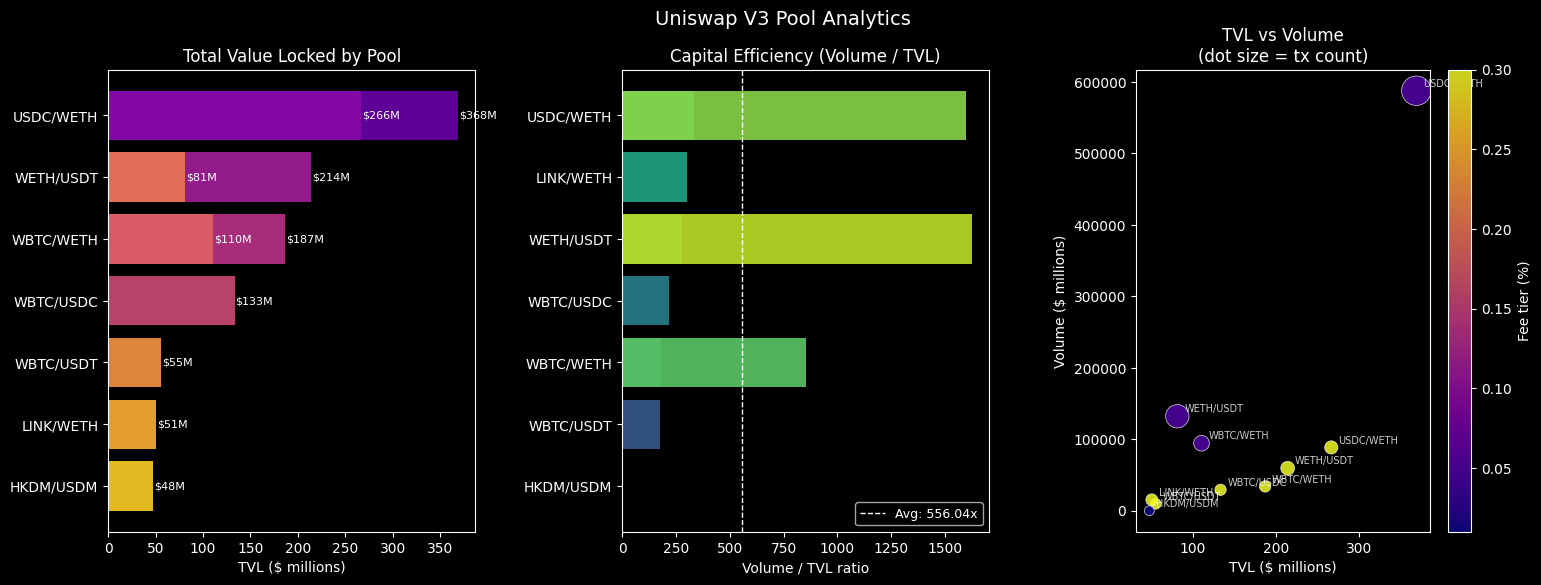

Chart saved as 03_defi_pools.png


In [8]:
# BLOCK 8 - Visualise Uniswap pool data

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Uniswap V3 Pool Analytics', fontsize=14)
plt.subplots_adjust(wspace=0.4)

cmap_colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(pools_df)))

# Chart 1: TVL ranking - which pools hold the most liquidity
ax = axes[0]
bars = ax.barh(pools_df['pair'], pools_df['tvl'] / 1e6, color=cmap_colors, alpha=0.9)
for bar, val in zip(bars, pools_df['tvl']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'${val/1e6:.0f}M', va='center', fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('TVL ($ millions)')
ax.set_title('Total Value Locked by Pool')

# Chart 2: Capital efficiency (volume / TVL)
# A higher ratio means the liquidity is being put to better use
ax = axes[1]
sorted_df = pools_df.sort_values('cap_efficiency', ascending=True)
bars = ax.barh(sorted_df['pair'], sorted_df['cap_efficiency'],
               color=plt.cm.viridis(np.linspace(0.2, 0.9, len(sorted_df))), alpha=0.9)
ax.axvline(pools_df['cap_efficiency'].mean(), color='white', ls='--', lw=1,
           label=f'Avg: {pools_df["cap_efficiency"].mean():.2f}x')
ax.set_xlabel('Volume / TVL ratio')
ax.set_title('Capital Efficiency (Volume / TVL)')
ax.legend(fontsize=9)

# Chart 3: Scatter - TVL vs Volume, sized by transaction count
# Interesting to see which pools are high-volume despite low TVL
ax = axes[2]
sizes = (pools_df['txs'] / pools_df['txs'].max()) * 400 + 50
sc = ax.scatter(pools_df['tvl'] / 1e6, pools_df['volume'] / 1e6,
                s=sizes, c=pools_df['fee_pct'], cmap='plasma',
                alpha=0.85, edgecolors='white', lw=0.5)
for _, row in pools_df.iterrows():
    ax.annotate(row['pair'], (row['tvl']/1e6, row['volume']/1e6),
                fontsize=7, alpha=0.8, xytext=(5, 3), textcoords='offset points')
plt.colorbar(sc, ax=ax, label='Fee tier (%)')
ax.set_xlabel('TVL ($ millions)')
ax.set_ylabel('Volume ($ millions)')
ax.set_title('TVL vs Volume\n(dot size = tx count)')

plt.savefig('03_defi_pools.png', dpi=130, bbox_inches='tight')
plt.show()
print('Chart saved as 03_defi_pools.png')

In [9]:
# BLOCK 9 - Market regime clustering with K-Means
# Idea: can we identify recurring market states (bull, bear, sideways)?
# We build features from price + volume and let K-Means group similar days

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Build a feature table from ETH price data
f = eth.copy()
f['vol30']     = f['return'].rolling(30).std() * np.sqrt(365)  # annualised volatility
f['ret5d']     = f['return'].rolling(5).mean()                  # 5-day momentum
f['vol_spike'] = f['volume'] / f['volume'].rolling(20).mean()   # volume vs recent average
f['drawdown']  = f['price'] / f['price'].rolling(60).max() - 1  # distance from 60d high
f['btc_corr']  = f['return'].rolling(20).corr(btc['return'])    # correlation with BTC
f = f.dropna()

features = ['return', 'vol30', 'ret5d', 'vol_spike', 'drawdown', 'btc_corr']
X = StandardScaler().fit_transform(f[features])

# Fit K-Means with 4 clusters (a reasonable number for market regimes)
km = KMeans(n_clusters=4, random_state=42, n_init=20)
f['cluster'] = km.fit_predict(X)

# PCA: reduce 6 features to 2D so we can plot the clusters
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X)
f['pc1'], f['pc2'] = coords[:, 0], coords[:, 1]

# Label clusters by sorting them on average return so labels are always unique
# Sort clusters from highest to lowest avg return, then assign fixed names
cluster_returns = f.groupby('cluster')['return'].mean().sort_values(ascending=False)
rank_to_label   = {0: 'Bull / Strong', 1: 'Bull / Weak', 2: 'Bear / Mild', 3: 'Bear / Selloff'}
labels = {cluster_id: rank_to_label[rank]
          for rank, cluster_id in enumerate(cluster_returns.index)}

print('Cluster summary (sorted by avg return):')
for rank, cluster_id in enumerate(cluster_returns.index):
    sub = f[f['cluster'] == cluster_id]
    print(f'  {labels[cluster_id]:16s}  n={len(sub):3d}  '
          f'avg ret={sub["return"].mean()*100:+.2f}%  '
          f'avg vol={sub["vol30"].mean():.2f}')

Cluster summary (sorted by avg return):
  Bull / Strong     n= 46  avg ret=+3.97%  avg vol=0.66
  Bull / Weak       n= 76  avg ret=-0.27%  avg vol=0.80
  Bear / Mild       n=118  avg ret=-0.42%  avg vol=0.62
  Bear / Selloff    n= 67  avg ret=-1.15%  avg vol=0.84


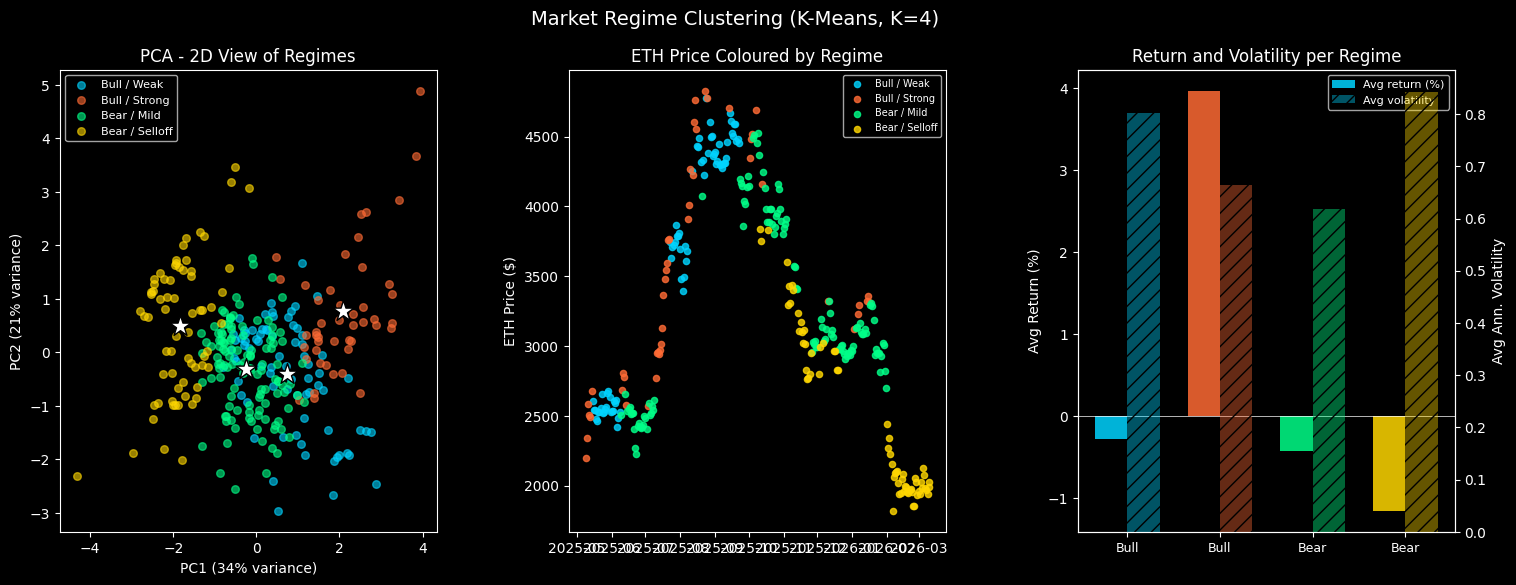

Chart saved as 04_clusters.png


In [10]:
# BLOCK 10 - Visualise the clusters

PALETTE = ['#00d4ff', '#ff6b35', '#00ff88', '#ffd700']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Market Regime Clustering (K-Means, K=4)', fontsize=14)
plt.subplots_adjust(wspace=0.35)

# Chart 1: PCA scatter - each dot is a day, coloured by cluster
ax = axes[0]
for c in range(4):
    mask = f['cluster'] == c
    ax.scatter(f.loc[mask, 'pc1'], f.loc[mask, 'pc2'],
               color=PALETTE[c], alpha=0.6, s=30, label=labels[c])
# Mark cluster centres
centers = pca.transform(km.cluster_centers_)
ax.scatter(centers[:, 0], centers[:, 1], marker='*', s=250,
           c='white', edgecolors='black', zorder=5)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.0f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.0f}% variance)')
ax.set_title('PCA - 2D View of Regimes')
ax.legend(fontsize=8)

# Chart 2: ETH price timeline coloured by regime
ax = axes[1]
for c in range(4):
    mask = f['cluster'] == c
    ax.scatter(f.loc[mask].index, f.loc[mask, 'price'],
               color=PALETTE[c], alpha=0.8, s=20, label=labels[c])
ax.set_title('ETH Price Coloured by Regime')
ax.set_ylabel('ETH Price ($)')
ax.legend(fontsize=7)

# Chart 3: Average return and volatility per cluster
ax = axes[2]
cluster_stats = f.groupby('cluster').agg(
    avg_return=('return', lambda x: x.mean() * 100),
    avg_vol=('vol30', 'mean')
).reset_index()
bar_w = 0.35
x = np.arange(4)
b1 = ax.bar(x - bar_w/2, cluster_stats['avg_return'], bar_w,
            color=PALETTE, alpha=0.85, label='Avg daily return (%)')
ax2 = ax.twinx()
b2 = ax2.bar(x + bar_w/2, cluster_stats['avg_vol'], bar_w,
             color=PALETTE, alpha=0.4, hatch='//', label='Avg volatility')
ax.axhline(0, color='white', lw=0.5)
ax.set_xticks(x)
ax.set_xticklabels([labels[c].split('/')[0].strip() for c in range(4)], fontsize=9)
ax.set_ylabel('Avg Return (%)')
ax2.set_ylabel('Avg Ann. Volatility')
ax.set_title('Return and Volatility per Regime')
handles = [b1, b2]
ax.legend(handles, ['Avg return (%)', 'Avg volatility'], fontsize=8)

plt.savefig('04_clusters.png', dpi=130, bbox_inches='tight')
plt.show()
print('Chart saved as 04_clusters.png')

In [11]:
# BLOCK 11 - cadCAD Model Setup
#
# cadCAD is a Python library for modelling complex systems using
# a simulation loop. We model a Uniswap-style AMM (Automated Market Maker).
#
# The AMM rule: ETH_reserve * USDC_reserve = k (constant)
# When someone buys ETH, they deposit USDC. The pool rebalances to keep k constant.
#
# We simulate two types of traders:
#   - Arbitrageurs: push pool price back toward real ETH price
#   - Retail traders: random noise trades

from cadCAD.configuration.utils import config_sim
from cadCAD.engine import ExecutionMode, ExecutionContext, Executor
# Removed: from cadCAD import configs

# cadCAD does not expose __version__ directly; use pkg_resources instead
try:
    import pkg_resources
    print(f'cadCAD version: {pkg_resources.get_distribution("cadCAD").version}')
except Exception:
    print('cadCAD imported OK')

# Use the last 180 real ETH prices as our oracle (external reference price)
REAL_PRICES = eth['price'].values[-180:].tolist()
INIT_PRICE  = REAL_PRICES[0]
INIT_ETH    = 1_000.0          # 1000 ETH in pool
INIT_USDC   = INIT_ETH * INIT_PRICE
FEE         = 0.003            # 0.3% trading fee

# Genesis state: what the system looks like at timestep 0
genesis = {
    'eth_reserve':  INIT_ETH,
    'usdc_reserve': INIT_USDC,
    'pool_price':   INIT_PRICE,
    'oracle_price': INIT_PRICE,
    'fees_total':   0.0,
    'volume_total': 0.0,
    'step_idx':     0,
}

print(f'Pool initialised:')
print(f'  ETH reserve:  {INIT_ETH:,}')
print(f'  USDC reserve: ${INIT_USDC:,.0f}')
print(f'  Start price:  ${INIT_PRICE:,.2f}')
print(f'  Steps to run: {len(REAL_PRICES) - 1} (one per day)')

cadCAD version: 0.5.3
Pool initialised:
  ETH reserve:  1,000.0
  USDC reserve: $4,708,842
  Start price:  $4,708.84
  Steps to run: 179 (one per day)


In [12]:
# BLOCK 12 - Define cadCAD policies and state update functions
#
# In cadCAD:
#   - Policies read the state and produce signals (decisions / actions)
#   - State update functions apply those signals to update the state

# Helper: spot price from reserves
def spot_price(eth_r, usdc_r):
    return usdc_r / eth_r

# Helper: constant-product swap (buy ETH with USDC)
def buy_eth(usdc_in, eth_r, usdc_r):
    usdc_in_net  = usdc_in * (1 - FEE)
    new_usdc     = usdc_r + usdc_in_net
    new_eth      = (eth_r * usdc_r) / new_usdc
    eth_out      = eth_r - new_eth
    fee_usdc     = usdc_in * FEE
    return eth_out, fee_usdc, new_eth, usdc_r + usdc_in

# Helper: constant-product swap (sell ETH for USDC)
def sell_eth(eth_in, eth_r, usdc_r):
    eth_in_net   = eth_in * (1 - FEE)
    new_eth      = eth_r + eth_in_net
    new_usdc     = (eth_r * usdc_r) / new_eth
    usdc_out     = usdc_r - new_usdc
    fee_usdc     = eth_in * FEE * (usdc_r / eth_r)
    return usdc_out, fee_usdc, eth_r + eth_in, new_usdc

# Policy 1: advance the oracle price using real historical data
def p_oracle(params, step, sL, state):
    next_idx   = min(state['step_idx'] + 1, len(REAL_PRICES) - 1)
    next_price = REAL_PRICES[next_idx]
    return {'new_oracle': next_price, 'new_idx': next_idx}

# Policy 2: arbitrageur closes price gap between pool and oracle
def p_arb(params, step, sL, state):
    pool_p   = spot_price(state['eth_reserve'], state['usdc_reserve'])
    oracle_p = state['oracle_price']
    gap      = (oracle_p - pool_p) / pool_p

    # Only trade if gap is bigger than the arb threshold parameter
    if abs(gap) < params['arb_threshold']:
        return {'arb_usdc': 0.0, 'arb_eth': 0.0}

    # Calculate how much to trade to close 80% of the gap
    k          = state['eth_reserve'] * state['usdc_reserve']
    target_p   = pool_p + 0.8 * (oracle_p - pool_p)
    if gap > 0:  # pool too cheap vs oracle -> buy ETH from pool
        usdc_in = max(0, np.sqrt(k * target_p) - state['usdc_reserve'])
        return {'arb_usdc': min(usdc_in, 500_000), 'arb_eth': 0.0}
    else:        # pool too expensive -> sell ETH into pool
        eth_in  = max(0, np.sqrt(k / target_p) - state['eth_reserve'])
        return {'arb_usdc': 0.0, 'arb_eth': min(eth_in, 200.0)}

# Policy 3: retail traders add random noise
def p_retail(params, step, sL, state):
    rng      = np.random.default_rng(seed=state['step_idx'] * 7 + 13)
    size     = state['usdc_reserve'] * rng.uniform(0.005, 0.02)
    direction = rng.choice([-1, 1])
    return {'retail_usdc': float(size * direction)}

# State update: apply oracle update
def su_oracle(params, step, sL, state, signal):
    return ('oracle_price', signal['new_oracle'])

def su_idx(params, step, sL, state, signal):
    return ('step_idx', signal['new_idx'])

# State update: apply all trades and update reserves + accounting
def su_eth_reserve(params, step, sL, state, signal):
    eth_r, usdc_r = state['eth_reserve'], state['usdc_reserve']
    fees, vol = 0.0, 0.0

    if signal.get('arb_usdc', 0) > 0:
        _, fee, eth_r, usdc_r = buy_eth(signal['arb_usdc'], eth_r, usdc_r)
        fees += fee; vol += signal['arb_usdc']

    if signal.get('arb_eth', 0) > 0:
        _, fee, eth_r, usdc_r = sell_eth(signal['arb_eth'], eth_r, usdc_r)
        fees += fee; vol += signal['arb_eth'] * state['oracle_price']

    retail = signal.get('retail_usdc', 0.0)
    if retail > 0:
        _, fee, eth_r, usdc_r = buy_eth(retail, eth_r, usdc_r)
        fees += fee; vol += retail
    elif retail < 0:
        eth_in = abs(retail) / spot_price(eth_r, usdc_r)
        _, fee, eth_r, usdc_r = sell_eth(eth_in, eth_r, usdc_r)
        fees += fee; vol += abs(retail)

    eth_r  = max(eth_r,  1.0)
    usdc_r = max(usdc_r, 1.0)
    # Pack all derived updates into a single tuple (cadCAD only picks first return value per variable)
    # We stash eth_r, usdc_r, fees, vol in the eth_reserve key as a dict and unpack elsewhere
    return ('eth_reserve', eth_r)

def su_usdc_reserve(params, step, sL, state, signal):
    eth_r, usdc_r = state['eth_reserve'], state['usdc_reserve']
    if signal.get('arb_usdc', 0) > 0:
        _, _, eth_r, usdc_r = buy_eth(signal['arb_usdc'], eth_r, usdc_r)
    if signal.get('arb_eth', 0) > 0:
        _, _, eth_r, usdc_r = sell_eth(signal['arb_eth'], eth_r, usdc_r)
    retail = signal.get('retail_usdc', 0.0)
    if retail > 0:
        _, _, eth_r, usdc_r = buy_eth(retail, eth_r, usdc_r)
    elif retail < 0:
        eth_in = abs(retail) / max(spot_price(eth_r, usdc_r), 1)
        _, _, eth_r, usdc_r = sell_eth(eth_in, eth_r, usdc_r)
    return ('usdc_reserve', max(usdc_r, 1.0))

def su_fees(params, step, sL, state, signal):
    eth_r, usdc_r = state['eth_reserve'], state['usdc_reserve']
    fees = 0.0
    if signal.get('arb_usdc', 0) > 0: fees += signal['arb_usdc'] * FEE
    if signal.get('arb_eth',  0) > 0: fees += signal['arb_eth'] * FEE * spot_price(eth_r, usdc_r)
    fees += abs(signal.get('retail_usdc', 0)) * FEE
    return ('fees_total', state['fees_total'] + fees)

def su_volume(params, step, sL, state, signal):
    vol  = signal.get('arb_usdc', 0)
    vol += signal.get('arb_eth', 0) * state['oracle_price']
    vol += abs(signal.get('retail_usdc', 0))
    return ('volume_total', state['volume_total'] + vol)

def su_pool_price(params, step, sL, state, signal):
    return ('pool_price', spot_price(state['eth_reserve'], state['usdc_reserve']))

print('Policies and state update functions defined.')

Policies and state update functions defined.


In [13]:
# BLOCK 13 - Run the cadCAD simulation
import cadCAD
from cadCAD.configuration import Experiment
from cadCAD.configuration.utils import config_sim
from cadCAD.engine import ExecutionMode, ExecutionContext, Executor

psubs = [
    {
        'label': 'Update oracle price',
        'policies':  {'oracle': p_oracle},
        'variables': {'oracle_price': su_oracle, 'step_idx': su_idx},
    },
    {
        'label': 'Traders act',
        'policies':  {'arb': p_arb, 'retail': p_retail},
        'variables': {
            'eth_reserve':  su_eth_reserve,
            'usdc_reserve': su_usdc_reserve,
            'fees_total':   su_fees,
            'volume_total': su_volume,
        },
    },
    {
        'label': 'Update derived state',
        'policies':  {},
        'variables': {'pool_price': su_pool_price},
    },
]

params = {
    'arb_threshold': [0.005, 0.020],  # two scenarios
}

sim_config = config_sim({'N': 1, 'T': range(len(REAL_PRICES) - 1), 'M': params})

exp = Experiment()
exp.append_configs(
    initial_state=genesis,
    partial_state_update_blocks=psubs,
    sim_configs=sim_config,
)

print(f'Configs registered: {len(exp.configs)}')  # should be 2 (one per scenario)

print(f'Running simulation ({len(REAL_PRICES)-1} steps x 2 scenarios)...')
exec_ctx = ExecutionContext(ExecutionMode().local_mode)
raw, _, _ = Executor(exec_ctx, exp.configs).execute()  # <-- exp.configs not cadCAD.configs

sim = pd.DataFrame(raw)
sim = sim[sim['timestep'] > 0].copy()
sim['scenario'] = sim['subset'].map({0: 'Tight arb (0.5%)', 1: 'Loose arb (2.0%)'})

dates = eth.index[-180:].values
sim['date'] = sim['timestep'].apply(lambda t: dates[min(t, len(dates)-1)])

print(f'Simulation done: {len(sim)} rows')
sim[['scenario','timestep','pool_price','oracle_price','fees_total']].tail(4)

Configs registered: 2
Running simulation (179 steps x 2 scenarios)...

                  ___________    ____
  ________ __ ___/ / ____/   |  / __ \
 / ___/ __` / __  / /   / /| | / / / /
/ /__/ /_/ / /_/ / /___/ ___ |/ /_/ /
\___/\__,_/\__,_/\____/_/  |_/_____/
by cadCAD

cadCAD Version: 0.5.3
Execution Mode: local_proc
Simulation Dimensions:
Entire Simulation: (Models, Unique Timesteps, Params, Total Runs, Sub-States) = (1, 179, 1, 2, 7)
     Simulation 0: (Timesteps, Params, Runs, Sub-States) = (179, 1, 2, 7)


Initializing configurations: 100%|██████████| 2/2 [00:00<00:00, 319.90it/s]

Execution Method: parallelize_simulations



Flattening results: 100%|██████████| 2/2 [00:00<00:00, 171.19it/s]

Total execution time: 0.29s
Simulation done: 1074 rows


,scenario,timestep,pool_price,oracle_price,fees_total
1072,Loose arb (2.0%),178,2003.851787,1992.355229,54064.433185
1073,Loose arb (2.0%),179,2003.851787,2029.336292,54064.433185
1074,Loose arb (2.0%),179,2003.851787,2029.336292,54210.276489
1075,Loose arb (2.0%),179,2067.240976,2029.336292,54210.276489


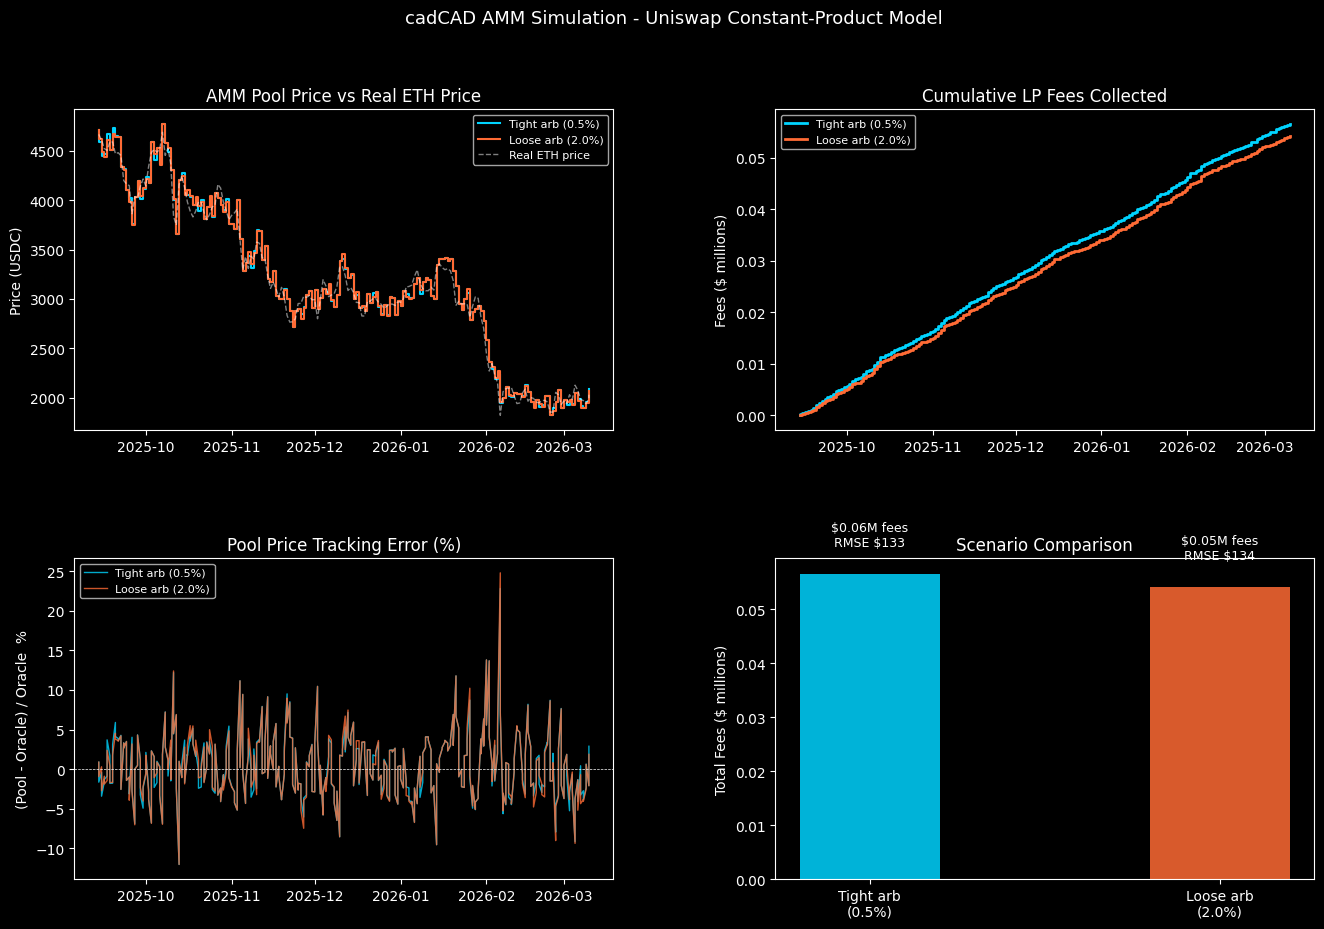

Chart saved as 05_cadcad.png


In [14]:
# BLOCK 14 - Visualise cadCAD results

SC = {0: '#00d4ff', 1: '#ff6b35'}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('cadCAD AMM Simulation - Uniswap Constant-Product Model', fontsize=13)
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# Chart 1: Pool price vs oracle (real ETH price)
# Good arb keeps the lines close together
ax = axes[0, 0]
for sid, label in {0: 'Tight arb (0.5%)', 1: 'Loose arb (2.0%)'}.items():
    sub = sim[sim['subset'] == sid]
    ax.plot(sub['date'], sub['pool_price'], color=SC[sid], lw=1.5, label=label)
sub0 = sim[sim['subset'] == 0]
ax.plot(sub0['date'], sub0['oracle_price'], color='white', lw=1, ls='--', alpha=0.5, label='Real ETH price')
ax.set_title('AMM Pool Price vs Real ETH Price')
ax.set_ylabel('Price (USDC)')
ax.legend(fontsize=8)

# Chart 2: Cumulative fees earned by liquidity providers
ax = axes[0, 1]
for sid, label in {0: 'Tight arb (0.5%)', 1: 'Loose arb (2.0%)'}.items():
    sub = sim[sim['subset'] == sid]
    ax.plot(sub['date'], sub['fees_total'] / 1e6, color=SC[sid], lw=2, label=label)
ax.set_title('Cumulative LP Fees Collected')
ax.set_ylabel('Fees ($ millions)')
ax.legend(fontsize=8)

# Chart 3: Price tracking error (pool vs oracle)
# Shows how efficiently each scenario keeps the pool in sync with reality
ax = axes[1, 0]
for sid, label in {0: 'Tight arb (0.5%)', 1: 'Loose arb (2.0%)'}.items():
    sub   = sim[sim['subset'] == sid]
    error = (sub['pool_price'] - sub['oracle_price']) / sub['oracle_price'] * 100
    ax.plot(sub['date'], error, color=SC[sid], lw=1, alpha=0.8, label=label)
ax.axhline(0, color='white', lw=0.5, ls='--')
ax.set_title('Pool Price Tracking Error (%)')
ax.set_ylabel('(Pool - Oracle) / Oracle  %')
ax.legend(fontsize=8)

# Chart 4: Final comparison bar chart
ax = axes[1, 1]
scenarios = ['Tight arb\n(0.5%)', 'Loose arb\n(2.0%)']
metrics   = []
for sid in [0, 1]:
    sub = sim[sim['subset'] == sid]
    rmse = np.sqrt(((sub['pool_price'] - sub['oracle_price'])**2).mean())
    metrics.append({'fees_M': sub['fees_total'].iloc[-1] / 1e6,
                    'rmse':   rmse,
                    'vol_M':  sub['volume_total'].iloc[-1] / 1e6})

x = np.arange(2)
fees_vals = [m['fees_M'] for m in metrics]
rmse_vals = [m['rmse'] for m in metrics]
bars = ax.bar(x, fees_vals, color=[SC[0], SC[1]], alpha=0.85, width=0.4)
for bar, (fv, rv) in zip(bars, zip(fees_vals, rmse_vals)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'${fv:.2f}M fees\nRMSE ${rv:.0f}', ha='center', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(scenarios)
ax.set_ylabel('Total Fees ($ millions)')
ax.set_title('Scenario Comparison')

plt.savefig('05_cadcad.png', dpi=130, bbox_inches='tight')
plt.show()
print('Chart saved as 05_cadcad.png')

In [15]:
# BLOCK 15 - Final summary
print('=' * 55)
print('  DEFI BLOCKCHAIN ANALYSIS - SUMMARY')
print('=' * 55)

print('\nMARKET DATA (365 days):')
print(f'  ETH: ${eth.price.iloc[-1]:,.0f}  |  1yr: {(eth.price.iloc[-1]/eth.price.iloc[0]-1)*100:+.0f}%')
print(f'  BTC: ${btc.price.iloc[-1]:,.0f}  |  1yr: {(btc.price.iloc[-1]/btc.price.iloc[0]-1)*100:+.0f}%')
print(f'  Correlation: {both["eth"].corr(both["btc"]):.2f}')

print('\nON-CHAIN (Etherscan - free endpoints):')
print(f'  Gas (standard): {gas_std:.4f} Gwei')
print(f'  ETH supply:     {supply_eth:,.0f} ETH')
print(f'  Current block:  {block_num:,}')
print(f'  Price check:    CoinGecko ${eth_price_cg:,.2f} vs Etherscan ${eth_usd_ethscan:,.2f} ({diff_pct:.3f}% diff)')

print('\nUNISWAP V3 (The Graph):')
print(f'  Top pool: {pools_df.iloc[0]["pair"]}  TVL ${pools_df["tvl"].iloc[0]/1e6:.0f}M')
print(f'  Combined TVL top-10: ${pools_df["tvl"].sum()/1e9:.1f}B')

print('\nMARKET REGIMES (K-Means, K=4):')
for c in range(4):
    sub = f[f['cluster'] == c]
    print(f'  {labels[c]:18s}: {len(sub)} days, avg ret {sub["return"].mean()*100:+.2f}%')

print('\ncadCAD AMM SIMULATION:')
for sid, label in {0: 'Tight arb (0.5%)', 1: 'Loose arb (2.0%)'}.items():
    sub  = sim[sim['subset'] == sid]
    rmse = np.sqrt(((sub['pool_price'] - sub['oracle_price'])**2).mean())
    print(f'  {label}: fees ${sub["fees_total"].iloc[-1]/1e6:.2f}M  RMSE ${rmse:.0f}')


  DEFI BLOCKCHAIN ANALYSIS - SUMMARY

MARKET DATA (365 days):
  ETH: $2,029  |  1yr: +8%
  BTC: $69,535  |  1yr: -12%
  Correlation: 0.84

ON-CHAIN (Etherscan - free endpoints):
  Gas (standard): 0.0455 Gwei
  ETH supply:     122,373,866 ETH
  Current block:  24,624,456
  Price check:    CoinGecko $2,029.34 vs Etherscan $2,028.55 (0.039% diff)

UNISWAP V3 (The Graph):
  Top pool: USDC/WETH  TVL $368M
  Combined TVL top-10: $1.5B

MARKET REGIMES (K-Means, K=4):
  Bull / Weak       : 76 days, avg ret -0.27%
  Bull / Strong     : 46 days, avg ret +3.97%
  Bear / Mild       : 118 days, avg ret -0.42%
  Bear / Selloff    : 67 days, avg ret -1.15%

cadCAD AMM SIMULATION:
  Tight arb (0.5%): fees $0.06M  RMSE $133
  Loose arb (2.0%): fees $0.05M  RMSE $134
